<a href="https://colab.research.google.com/github/shounik1904-crypto/Interelite-Minor-Project/blob/main/DIABETES_RISK_PREDICTOR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

All Libraries Loaded Successfully!

Upload diabetes.csv file


Saving diabetes.csv to diabetes (2).csv

Dataset Loaded Successfully
Dataset Shape: (768, 9)

First 5 Rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------    

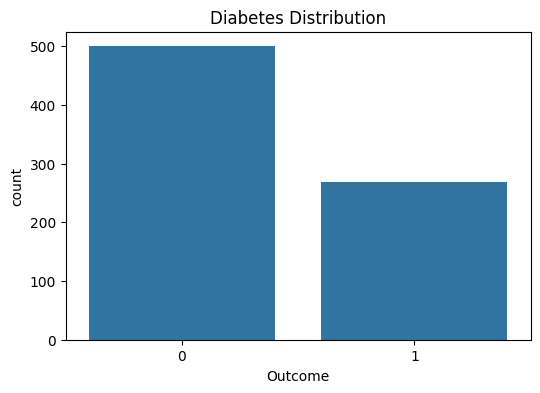

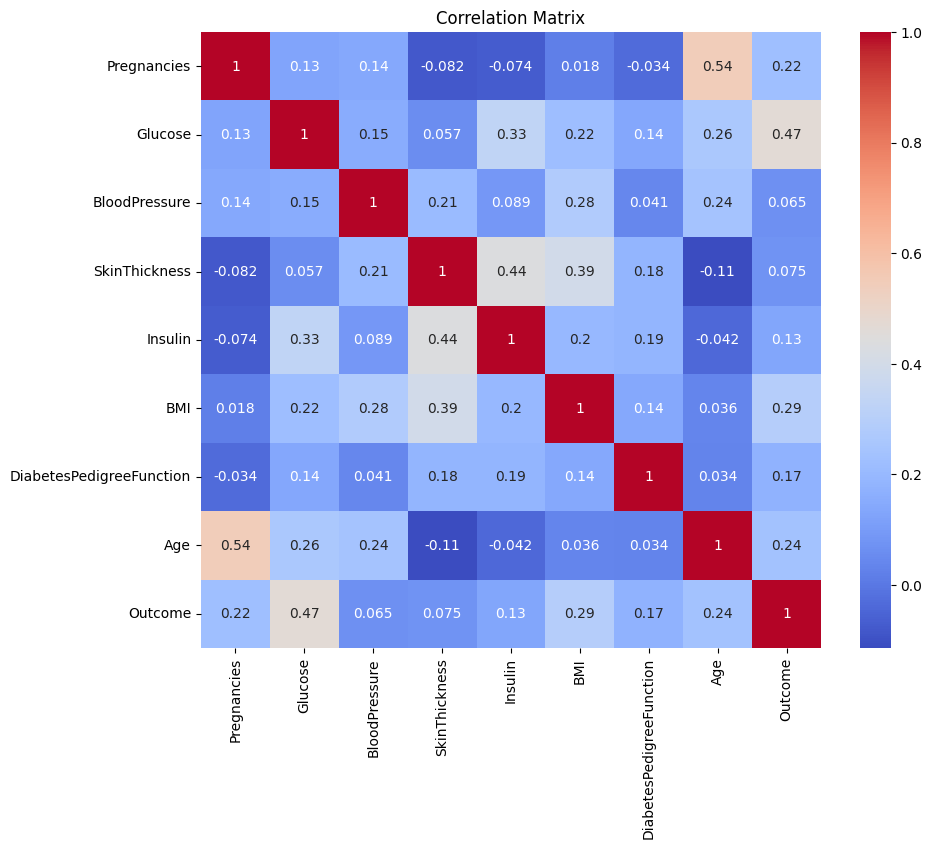


Training Shape: (614, 8)
Testing Shape: (154, 8)

Logistic Regression Accuracy: 75.32 %
SVM Accuracy: 72.73 %
Decision Tree Accuracy: 79.22 %

Model Comparison
                 Model   Accuracy
0  Logistic Regression  75.324675
1                  SVM  72.727273
2        Decision Tree  79.220779


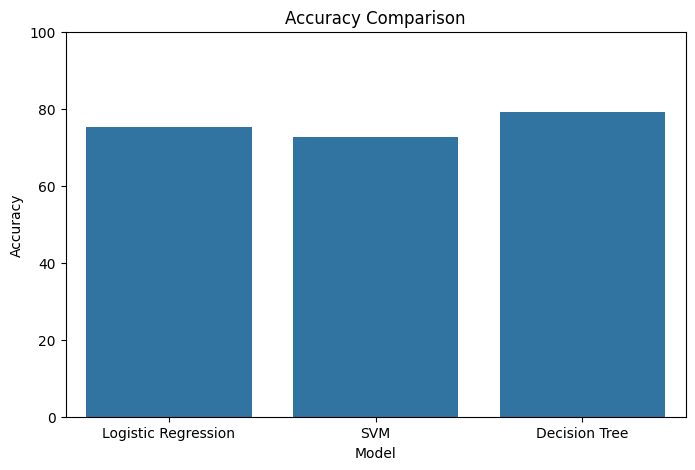


Best Model: Decision Tree

Classification Report
              precision    recall  f1-score   support

           0       0.81      0.88      0.84        99
           1       0.74      0.64      0.69        55

    accuracy                           0.79       154
   macro avg       0.78      0.76      0.77       154
weighted avg       0.79      0.79      0.79       154



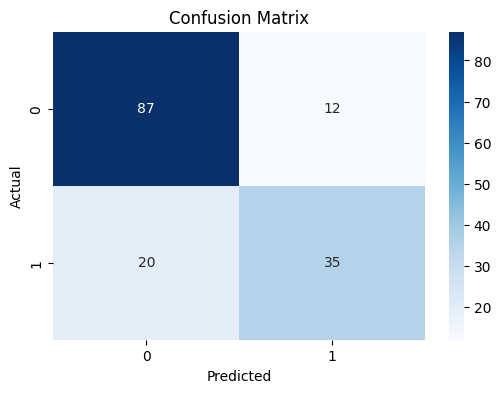

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



Sample Prediction
High Risk of Diabetes

DIABETES RISK PREDICTOR
Pregnancies: 6
Glucose: 148
Blood Pressure: 72
Skin Thickness: 35
Insulin: 0
BMI: 33.6
Diabetes Pedigree Function: 0.627
Age: 50

Prediction Result
Patient is likely DIABETIC

Project Execution Completed Successfully!


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
# ==========================================================
# DIABETES RISK PREDICTOR USING ML
# Algorithms: Logistic Regression, SVM, Decision Tree
# Platform: Google Colab
# ==========================================================

# -----------------------------
# STEP 1: IMPORT LIBRARIES
# -----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print("All Libraries Loaded Successfully!")

# -----------------------------
# STEP 2: UPLOAD DATASET
# -----------------------------
print("\nUpload diabetes.csv file")
uploaded = files.upload()

# -----------------------------
# STEP 3: LOAD DATASET
# -----------------------------
df = pd.read_csv("diabetes.csv")

print("\nDataset Loaded Successfully")
print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())

# -----------------------------
# STEP 4: DATA INFORMATION
# -----------------------------
print("\nDataset Information")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nStatistical Summary")
print(df.describe())

# -----------------------------
# STEP 5: DATA VISUALIZATION
# -----------------------------
plt.figure(figsize=(6,4))
sns.countplot(x='Outcome', data=df)
plt.title("Diabetes Distribution")
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# -----------------------------
# STEP 6: FEATURE SELECTION
# -----------------------------
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# -----------------------------
# STEP 7: FEATURE SCALING
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# STEP 8: TRAIN TEST SPLIT
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

# -----------------------------
# STEP 9: LOGISTIC REGRESSION
# -----------------------------
log_model = LogisticRegression()

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

log_acc = accuracy_score(y_test, log_pred)

print("\nLogistic Regression Accuracy:",
      round(log_acc*100,2), "%")

# -----------------------------
# STEP 10: SVM
# -----------------------------
svm_model = SVC(kernel='rbf')

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

svm_acc = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:",
      round(svm_acc*100,2), "%")

# -----------------------------
# STEP 11: DECISION TREE
# -----------------------------
tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

tree_acc = accuracy_score(y_test, tree_pred)

print("Decision Tree Accuracy:",
      round(tree_acc*100,2), "%")

# -----------------------------
# STEP 12: MODEL COMPARISON
# -----------------------------
results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "SVM",
        "Decision Tree"
    ],
    "Accuracy":[
        log_acc*100,
        svm_acc*100,
        tree_acc*100
    ]
})

print("\nModel Comparison")
print(results)

plt.figure(figsize=(8,5))
sns.barplot(
    x="Model",
    y="Accuracy",
    data=results
)

plt.title("Accuracy Comparison")
plt.ylim(0,100)
plt.show()

# -----------------------------
# STEP 13: BEST MODEL REPORT
# -----------------------------
best_model_name = max(
    {
        "Logistic Regression": log_acc,
        "SVM": svm_acc,
        "Decision Tree": tree_acc
    },
    key=lambda x: {
        "Logistic Regression": log_acc,
        "SVM": svm_acc,
        "Decision Tree": tree_acc
    }[x]
)

print("\nBest Model:", best_model_name)

if best_model_name == "Logistic Regression":
    best_pred = log_pred

elif best_model_name == "SVM":
    best_pred = svm_pred

else:
    best_pred = tree_pred

print("\nClassification Report")
print(classification_report(y_test, best_pred))

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# -----------------------------
# STEP 14: SAMPLE PREDICTION
# -----------------------------
sample = [[
    6,
    148,
    72,
    35,
    0,
    33.6,
    0.627,
    50
]]

sample = scaler.transform(sample)

prediction = svm_model.predict(sample)

print("\nSample Prediction")

if prediction[0] == 1:
    print("High Risk of Diabetes")
else:
    print("Low Risk of Diabetes")

# -----------------------------
# STEP 15: USER INPUT PREDICTION
# -----------------------------
print("\n==============================")
print("DIABETES RISK PREDICTOR")
print("==============================")

preg = float(input("Pregnancies: "))
glu = float(input("Glucose: "))
bp = float(input("Blood Pressure: "))
skin = float(input("Skin Thickness: "))
ins = float(input("Insulin: "))
bmi = float(input("BMI: "))
dpf = float(input("Diabetes Pedigree Function: "))
age = float(input("Age: "))

user_data = [[
    preg,
    glu,
    bp,
    skin,
    ins,
    bmi,
    dpf,
    age
]]

user_data = scaler.transform(user_data)

result = svm_model.predict(user_data)

print("\nPrediction Result")

if result[0] == 1:
    print("Patient is likely DIABETIC")
else:
    print("Patient is likely NON-DIABETIC")

print("\nProject Execution Completed Successfully!")